# Establishing the Analysis Zone
## Importance of defining the zone of interest
The first step when performing these type of analysis is to define the spatio-temporal extent of the studied region. This will serve as the baseline for the analysis where all the data will be layered and results will be extracted for it. It will also let the performed work to be reproducible by others. In other words, it will give the same common language among stakeholders avoiding misunderstandings.  

## How to define it? 
Most of the times, the zone definition is based on prestablished administrative boundaries, like country, state/province, city, etc. In other cases, the client might have its own definition and might provide a verbal description or geo reference for it.

An important consideration when working with administrative boudaries is that they can be modified over time and this must be acknowledged, specially when performing longitudinal analysis. For example, suppose we have the task of calculating the population density across the European Union. We have a dataset that provides number of people across the years and a georeferenced vector layer with the extent of the region. To calculate the population density we just need to divide the population by the region's area. However, is the area going to be the same across years? How should we consider that? 

The following maps show the differences in the European Union extent in 2021 vs 2010. The data was downloaded from [here](https://ec.europa.eu/eurostat/web/gisco/geodata/reference-data/administrative-units-statistical-units/nuts#nuts21)

In [ ]:
# import the required libraries
import geopandas as gpd
import folium

In [ ]:
# read the data for the EU extent for 2010 and 2021
data_2021 = gpd.read_file('../data/NUTS_RG_20M_2021_3035.geojson')
data_2010 = gpd.read_file('../data/NUTS_RG_20M_2010_3035.geojson')

In [ ]:
# create a map where students can turn layers on/off and see the changes through time
m = data_2021[data_2021['LEVL_CODE']==0].explore(color = 'deeppink', name = 'members 2021')
data_2010[data_2010['LEVL_CODE']==0].explore(m=m, color = 'royalblue', name = 'members 2010')
folium.LayerControl().add_to(m)
m

Antoher consideration for defining the analysis zone is whether the analysis will be compared with past ones. In that case, the definition used previously will be the one to use here.

## Border error
This error is about the fact that when a limit is defined, anything outside it is not being considered. For example, when studying trips to the CBD one might not count the ones originated outside the studied region. Thus, there is a number of trips going to the CBD but which are not being counted. The way to deal with this error is by just acknowledging it. 

## Geographic level
The region of study will present geographic subdivisions for which data will be summarized. For example, the US Census Bureau has:
- State
- County
- Tract
- Block Group
- Block

In this case, the levels are nested, by aggregating blocks one can get the block groups, by aggregating block groups one can get the tracts and so on. 

### Administrative Boundaries Across the Globe
There is common international agreement to call administrative levels from 0 to 4. Level 0 represents the Country, level 1 represent the State/Province, level 2 district/county, level 3 and 4 are higher levels and its availability depends on the country. These levels are supposed to be nested and consistent. The key challenge is that the name of the administrative boundaries and the number of them, change by country. Also, higher geography levels like municipalities depend on the political system of the country and is harder to find information (georreferenced or not) about it. 

The following map shows the administrative levels for Uganda and it was extracted from [GADM](https://gadm.org/download_country.html)
According to the documentation:
>Uganda administrative level 0 (country), 1 (region), 2 (district), 3 (county), and 4 (sub-country) boundaries. 

Use the layers on/off button to explore the different administrative levels. 

In [ ]:
# load the data
uga0 = gpd.read_file('../data/gadm41_UGA_shp/gadm41_UGA_0.shp')
uga1 = gpd.read_file('../data/gadm41_UGA_shp/gadm41_UGA_1.shp')
uga2 = gpd.read_file('../data/gadm41_UGA_shp/gadm41_UGA_2.shp')
uga3 = gpd.read_file('../data/gadm41_UGA_shp/gadm41_UGA_3.shp')
uga4 = gpd.read_file('../data/gadm41_UGA_shp/gadm41_UGA_4.shp')

In [ ]:
# create the map
m = uga0.explore(name = 'level 0', color = 'none', style_kwds=dict(color='royalblue'))
uga1.explore(m = m, name = 'level 1', color = 'none', style_kwds=dict(color='deeppink'))
uga2.explore(m = m, name = 'level 2', color = 'none', style_kwds=dict(color='seagreen'))
uga3.explore(m = m, name = 'level 3', color = 'none', style_kwds=dict(color='purple'))
uga4.explore(m = m, name = 'level 4', color = 'none', style_kwds=dict(color='grey'))
folium.LayerControl().add_to(m) #add a control for layers
m

#### Sources to get Administrative boundaries
- [GADM](https://gadm.org/about.html)
- [geoBoundaries](https://www.geoboundaries.org/)
- [Humanitarian Data Exchange](https://data.humdata.org/search?q=subnational+boundaries&ext_search_source=main-nav)


### H3 - Hexagonal hierarchical geospatial indexing system
The H3 grid system was developed by Uber and it is open source. This grid partitions the world into hexagons of different sizes which are also nested, as depicted by the image

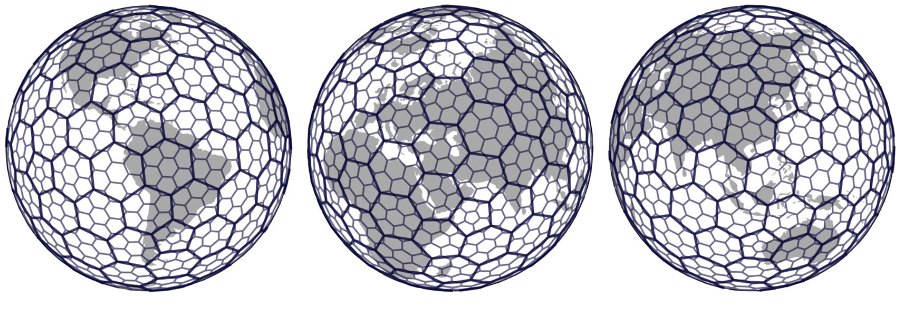

https://www.uber.com/blog/h3/ 

### What level should I use? 
The first question to be asked is which data aggregation level is available. So, if the data is available at the State level, then, no more granular analysis, like at the municipal level could be performed, unless a desaggregation process is followed. The next question is the purpose of the analysis and who will be using it. 

## Disputed Boundaries
In sensitive cases where boundaries are being disputed and the map owner does not take part in the dispute, it is a good practice to 
(search for an example)

## Excercises
Now is your turn 
Create a map for xxxxxxxxxx. The data sets can be found in one of the listed sources in the `Data Sources` presentation